In [1]:
import numpy as np
import pandas as pd
import joblib
import re
from scipy.spatial.distance import euclidean, cosine

np.random.seed(42)

In [2]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import numpy as np
import joblib
from scipy.spatial.distance import cosine

# Define the exact folder path where your data lives
DATA_DIR = r"/Users/shaiknaveedahmed/Desktop/Multi-Modal Biometric"

# Load fingerprint and iris data
print("Loading data...")
fp_data = joblib.load(os.path.join(DATA_DIR, 'enhanced_fingerprint_features.pkl'))
fp_features_dict = fp_data['features']

# Load minutiae points
if 'minutiae_points' in fp_data:
    fp_minutiae_dict = fp_data['minutiae_points']
    print("Loaded minutiae points from pickle.")
else:
    print("ERROR: minutiae_points not found in fingerprint pickle!")
    print("Please re-run fingerprint pipeline to save minutiae points.")
    exit()

ir_f = np.load(os.path.join(DATA_DIR, 'iris_features.npy'))
ir_l = np.load(os.path.join(DATA_DIR, 'iris_labels.npy'))

# ============================================================
# STEP 1: Define ENHANCED fingerprint matcher (returns similarity score)
# ============================================================
class EnhancedSimpleMatcher:
    def __init__(self):
        self.global_mean = None
        self.global_std = None
        self.fitted = False
    
    def fit(self, all_features_list):
        """Fit normalizer on all triangle features"""
        all_feats = np.vstack(all_features_list)
        self.global_mean = np.mean(all_feats, axis=0)
        self.global_std = np.std(all_feats, axis=0)
        self.global_std[self.global_std == 0] = 1
        self.fitted = True
        return self
    
    def extract_robust_features(self, df):
        """Extract robust features from triangle DataFrame"""
        feats = df.select_dtypes(include=[np.number]).values
        
        if len(feats) == 0:
            return np.zeros(100)
        
        # Normalize if fitted
        if self.fitted and self.global_mean is not None:
            feats = (feats - self.global_mean) / self.global_std
        
        # Multiple statistics for better discrimination
        mean_vec = np.mean(feats, axis=0)
        std_vec = np.std(feats, axis=0)
        
        # Percentiles (more robust than mean only)
        percentiles = np.percentile(feats, [10, 25, 50, 75, 90], axis=0)
        p10 = percentiles[0]
        p25 = percentiles[1]
        p50 = percentiles[2]
        p75 = percentiles[3]
        p90 = percentiles[4]
        
        # Combine all features (mean, std, percentiles)
        combined = np.concatenate([mean_vec, std_vec, p10, p25, p50, p75, p90])
        
        # L2 normalize
        norm = np.linalg.norm(combined)
        if norm > 0:
            combined = combined / norm
        
        return combined
    
    def compare(self, df1, df2, pts1, pts2, quality1=0.5, quality2=0.5):
        """Returns a similarity score between two fingerprints (0 to 1)"""
        # Extract robust feature vectors
        feat1 = self.extract_robust_features(df1)
        feat2 = self.extract_robust_features(df2)
        
        # Multiple similarity measures
        cos_sim = 1 - cosine(feat1, feat2)
        
        # Euclidean similarity
        euclidean_dist = np.linalg.norm(feat1 - feat2)
        euc_sim = 1 / (1 + euclidean_dist)
        
        # Correlation similarity
        corr_sim = np.corrcoef(feat1, feat2)[0, 1] if len(feat1) > 1 else 0.5
        corr_sim = max(0, min(1, corr_sim))
        
        # Weighted combination
        sim = 0.5 * cos_sim + 0.3 * euc_sim + 0.2 * corr_sim
        
        # Quality adjustment
        quality_factor = (quality1 + quality2) / 2
        sim = sim * (0.7 + 0.3 * quality_factor)
        
        return np.clip(sim, 0.0, 1.0)

# Initialize and fit matcher
print("Building triangle feature list for normalization...")
all_triangle_feats = []
for fid, df in fp_features_dict.items():
    feats = df.select_dtypes(include=[np.number]).values
    if len(feats) > 0:
        all_triangle_feats.append(feats)

matcher = EnhancedSimpleMatcher()
matcher.fit(all_triangle_feats)
print("EnhancedSimpleMatcher loaded successfully.")

# ============================================================
# STEP 2: Enrollment Data (First sample per person)
# ============================================================
print("Collecting all person IDs...")
person_ids_from_fp = set()
for fid in fp_features_dict.keys():
    match = re.search(r'_(\d+)_', fid)
    if match:
        person_ids_from_fp.add(match.group(1).zfill(3))

# Store first sample of each person as enrollment template
enrollment_fp = {}  # person -> (df, minutiae, feature_vector)
enrollment_fids = {}

for person in sorted(list(person_ids_from_fp)):
    for fid, df in fp_features_dict.items():
        match = re.search(r'_(\d+)_', fid)
        if match and match.group(1).zfill(3) == person:
            enrollment_fp[person] = {
                'df': df,
                'points': fp_minutiae_dict[fid],
                'feature': matcher.extract_robust_features(df)
            }
            enrollment_fids[person] = fid
            break

print(f"Enrollment templates created for {len(enrollment_fp)} persons.")

# ============================================================
# STEP 3: For each fingerprint, we store a 1D similarity?
# Actually for feature-level fusion, we need a fixed-length vector.
# But since we want to use original matcher, we'll use 1D score.
# ============================================================
# For now, we'll just store the feature vector for each fingerprint
# The matching will be done using the matcher directly

person_fp = {}  # person -> list of feature vectors (multiple samples)
for fid, df in fp_features_dict.items():
    match = re.search(r'_(\d+)_', fid)
    if not match:
        continue
    person_str = match.group(1).zfill(3)
    if person_str not in person_fp:
        person_fp[person_str] = []
    person_fp[person_str].append(matcher.extract_robust_features(df))

# ============================================================
# STEP 4: Aggregate Iris by Person
# ============================================================
person_ir = {}
for feats, label in zip(ir_f, ir_l):
    person_str = str(label).zfill(3)
    if person_str not in person_ir:
        person_ir[person_str] = []
    person_ir[person_str].append(feats)

# Normalise iris features
all_iris = np.array([feat for feats in person_ir.values() for feat in feats])
iris_mean = np.mean(all_iris, axis=0)
iris_std = np.std(all_iris, axis=0)
iris_std[iris_std == 0] = 1

person_ir_norm = {}
for person, feats_list in person_ir.items():
    person_ir_norm[person] = []
    for feats in feats_list:
        feats_norm = (feats - iris_mean) / iris_std
        feats_norm = feats_norm / (np.linalg.norm(feats_norm) + 1e-8)
        person_ir_norm[person].append(feats_norm)
person_ir = person_ir_norm

# ============================================================
# STEP 5: Find overlapping persons and set dimensions
# ============================================================
common_persons = sorted(list(set(person_fp.keys()).intersection(set(person_ir.keys()))))
print(f"Found {len(common_persons)} overlapping persons.")

# For feature-level fusion, we still need a fixed-length vector.
# We'll use the robust feature vector (125D) as the fingerprint feature
NUM_FP_FEATURES = person_fp[common_persons[0]][0].shape[0]  # ~125D
NUM_IRIS_FEATURES = 10

print(f"Fingerprint feature length (robust features): {NUM_FP_FEATURES}D")
print(f"Iris feature length (normalised):             {NUM_IRIS_FEATURES}D")
print(f"Total fused vector dimension: {NUM_FP_FEATURES + NUM_IRIS_FEATURES}D")

Loading data...
Loaded minutiae points from pickle.
Building triangle feature list for normalization...
EnhancedSimpleMatcher loaded successfully.
Enrollment templates created for 110 persons.
Found 108 overlapping persons.
Fingerprint feature length (robust features): 175D
Iris feature length (normalised):             10D
Total fused vector dimension: 185D


In [4]:
# Generate ONE fixed matrix for ALL users
FIXED_SEED = 42
FIXED_SIZE = NUM_FP_FEATURES + NUM_IRIS_FEATURES  # ~125 + 10 = ~135

rng = np.random.RandomState(FIXED_SEED)
random_matrix = rng.randn(FIXED_SIZE, FIXED_SIZE)
FIXED_MATRIX, R = np.linalg.qr(random_matrix)

def fuse_features(fp_features, iris_features):
    """No PIN needed - uses fixed matrix"""
    V = np.concatenate([fp_features, iris_features])
    return np.dot(FIXED_MATRIX, V)

def reverse_fusion(fused_template, fp_size, iris_size):
    """No PIN needed - uses fixed matrix transpose"""
    recovered_V = np.dot(FIXED_MATRIX.T, fused_template)
    recovered_fp = recovered_V[:fp_size]
    recovered_iris = recovered_V[fp_size:]
    return recovered_fp, recovered_iris

In [5]:
print("--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---")

database_templates = {}

for person in common_persons:
    # Take their first sample for enrollment
    fp_enroll = person_fp[person][0]
    ir_enroll = person_ir[person][0]
    
    # Perform Matrix Fusion using the FIXED matrix (no PIN needed)
    template = fuse_features(fp_enroll, ir_enroll)
    
    # Save to "Database"
    database_templates[person] = template

print(f"Successfully generated 60D cancelable templates for {len(database_templates)} users.")
print(f"All users share the SAME fixed projection matrix (no user-specific tokens).")

--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---
Successfully generated 60D cancelable templates for 108 users.
All users share the SAME fixed projection matrix (no user-specific tokens).


In [6]:
print("\n--- AUTHENTICATION SIMULATION (WITH FIXED THRESHOLD = 0.85) ---\n")

FIXED_THRESHOLD = 0.85

correct_fp_only = 0
correct_iris_only = 0
correct_fused = 0
total_attempts = len(common_persons)

# Fusion weights (iris dominant)
alpha = 0.30   # fingerprint weight
beta = 0.70    # iris weight

print(f"Fixed Threshold: {FIXED_THRESHOLD}")
print(f"Fusion weights: Fingerprint = {alpha}, Iris = {beta}")
print(f"Fingerprint feature dimension: {NUM_FP_FEATURES}D")
print(f"Iris feature dimension: {NUM_IRIS_FEATURES}D")

# Store all distances for normalisation
all_fp_distances = []
all_ir_distances = []

# First pass: collect all distances
for true_person in common_persons:
    live_fp = person_fp[true_person][1]  # second sample
    live_ir = person_ir[true_person][1]
    
    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
        dist_fp = cosine(live_fp, recovered_fp)
        dist_ir = cosine(live_ir, recovered_ir)
        all_fp_distances.append(dist_fp)
        all_ir_distances.append(dist_ir)

# Compute min/max for normalisation
fp_min, fp_max = np.min(all_fp_distances), np.max(all_fp_distances)
ir_min, ir_max = np.min(all_ir_distances), np.max(all_ir_distances)

if fp_max == fp_min:
    fp_max = fp_min + 1e-8
if ir_max == ir_min:
    ir_max = ir_min + 1e-8

print(f"Fingerprint distance range: [{fp_min:.4f}, {fp_max:.4f}]")
print(f"Iris distance range: [{ir_min:.4f}, {ir_max:.4f}]")

# Second pass: actual identification
for true_person in common_persons:
    live_fp = person_fp[true_person][1]
    live_ir = person_ir[true_person][1]
    
    best_matching_person_fp = None
    best_matching_person_ir = None
    best_matching_person_fused = None
    
    min_dist_fp = float('inf')
    min_dist_ir = float('inf')
    min_dist_fused = float('inf')

    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
        
        # Raw cosine distances
        dist_fp_raw = cosine(live_fp, recovered_fp)
        dist_ir_raw = cosine(live_ir, recovered_ir)
        
        # Normalise distances to [0,1] range
        dist_fp_norm = (dist_fp_raw - fp_min) / (fp_max - fp_min)
        dist_ir_norm = (dist_ir_raw - ir_min) / (ir_max - ir_min)
        
        # Convert to similarity scores (1 - distance)
        sim_fp = 1.0 - dist_fp_norm
        sim_ir = 1.0 - dist_ir_norm
        
        # Weighted fusion similarity
        sim_fused = (alpha * sim_fp) + (beta * sim_ir)
        
        # Convert back to distance for comparison
        dist_fp = 1.0 - sim_fp
        dist_ir = 1.0 - sim_ir
        dist_fused = 1.0 - sim_fused
        
        # Case 1: Fingerprint Only
        if dist_fp < min_dist_fp:
            min_dist_fp = dist_fp
            best_matching_person_fp = db_person
            
        # Case 2: Iris Only
        if dist_ir < min_dist_ir:
            min_dist_ir = dist_ir
            best_matching_person_ir = db_person
            
        # Case 3: Score-level fusion
        if dist_fused < min_dist_fused:
            min_dist_fused = dist_fused
            best_matching_person_fused = db_person

    # Tally results
    if best_matching_person_fp == true_person:
        correct_fp_only += 1
    if best_matching_person_ir == true_person:
        correct_iris_only += 1
    if best_matching_person_fused == true_person:
        correct_fused += 1

print(f"\nIDENTIFICATION RESULTS (Threshold = {FIXED_THRESHOLD}):")
print("=" * 60)
print(f"Case 1 (Fingerprint Only):   {correct_fp_only}/{total_attempts} ({(correct_fp_only / total_attempts) * 100:.2f}%)")
print(f"Case 2 (Iris Only):          {correct_iris_only}/{total_attempts} ({(correct_iris_only / total_attempts) * 100:.2f}%)")
print(f"Case 3 (Fingerprint + Iris): {correct_fused}/{total_attempts} ({(correct_fused / total_attempts) * 100:.2f}%)")
print("=" * 60)
print(f"Fusion weights: Fingerprint = {alpha}, Iris = {beta}")
print(f"Operating threshold: Similarity > {FIXED_THRESHOLD}")


--- AUTHENTICATION SIMULATION (WITH FIXED THRESHOLD = 0.85) ---

Fixed Threshold: 0.85
Fusion weights: Fingerprint = 0.3, Iris = 0.7
Fingerprint feature dimension: 175D
Iris feature dimension: 10D
Fingerprint distance range: [0.0165, 0.5287]
Iris distance range: [0.0001, 1.9011]

IDENTIFICATION RESULTS (Threshold = 0.85):
Case 1 (Fingerprint Only):   16/108 (14.81%)
Case 2 (Iris Only):          108/108 (100.00%)
Case 3 (Fingerprint + Iris): 106/108 (98.15%)
Fusion weights: Fingerprint = 0.3, Iris = 0.7
Operating threshold: Similarity > 0.85


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.metrics import roc_curve, auc

print("--- GENUINE VS IMPOSTOR SCORE GENERATION ---\n")

alpha = 0.30   # fingerprint weight
beta = 0.70    # iris weight

print(f"Using fusion weights: FP = {alpha}, Iris = {beta}")

genuine_scores_fp = []
impostor_scores_fp = []

genuine_scores_ir = []
impostor_scores_ir = []

genuine_scores_fused = []
impostor_scores_fused = []

# Compute min/max for normalisation if not already defined
try:
    fp_min, fp_max
    ir_min, ir_max
except NameError:
    all_fp_distances = []
    all_ir_distances = []
    for claiming_person in common_persons:
        live_fp = person_fp[claiming_person][1]    
        live_ir = person_ir[claiming_person][1]
        for db_person, stored_template in database_templates.items():
            recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
            all_fp_distances.append(cosine(live_fp, recovered_fp))
            all_ir_distances.append(cosine(live_ir, recovered_ir))
    fp_min, fp_max = np.min(all_fp_distances), np.max(all_fp_distances)
    ir_min, ir_max = np.min(all_ir_distances), np.max(all_ir_distances)
    if fp_max == fp_min:
        fp_max = fp_min + 1e-8
    if ir_max == ir_min:
        ir_max = ir_min + 1e-8

print(f"Fingerprint distance range: [{fp_min:.4f}, {fp_max:.4f}]")
print(f"Iris distance range: [{ir_min:.4f}, {ir_max:.4f}]")

# Loop over every live person claiming identities
for claiming_person in common_persons:
    live_fp = person_fp[claiming_person][1]    
    live_ir = person_ir[claiming_person][1]
    
    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)

        # Raw cosine distances
        dist_fp_raw = cosine(live_fp, recovered_fp)
        dist_ir_raw = cosine(live_ir, recovered_ir)
        
        # Normalise distances to [0,1] range
        dist_fp_norm = (dist_fp_raw - fp_min) / (fp_max - fp_min)
        dist_ir_norm = (dist_ir_raw - ir_min) / (ir_max - ir_min)
        
        # Convert to similarity scores (1 - distance)
        sim_fp = 1.0 - dist_fp_norm
        sim_ir = 1.0 - dist_ir_norm
        
        # Weighted fusion similarity
        sim_fused = (alpha * sim_fp) + (beta * sim_ir)
        
        if claiming_person == db_person:
            genuine_scores_fp.append(sim_fp)
            genuine_scores_ir.append(sim_ir)
            genuine_scores_fused.append(sim_fused)
        else:
            impostor_scores_fp.append(sim_fp)
            impostor_scores_ir.append(sim_ir)
            impostor_scores_fused.append(sim_fused)

print(f"Generated {len(genuine_scores_fused)} Genuine Scores.")
print(f"Generated {len(impostor_scores_fused)} Impostor Scores.")

--- GENUINE VS IMPOSTOR SCORE GENERATION ---

Using fusion weights: FP = 0.3, Iris = 0.7
Fingerprint distance range: [0.0165, 0.5287]
Iris distance range: [0.0001, 1.9011]
Generated 108 Genuine Scores.
Generated 11556 Impostor Scores.


FINAL EVALUATION WITH FIXED THRESHOLD = 0.85

🔍 CASE 1: FINGERPRINT ONLY

📊 FINGERPRINT ONLY
  ROC-AUC Score:           0.8302
  Equal Error Rate (EER):  24.84%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     85/108 (78.70%)
  Impostor Accept (FP):    3325/11556 (28.7729%)
  Accuracy:                71.2963%


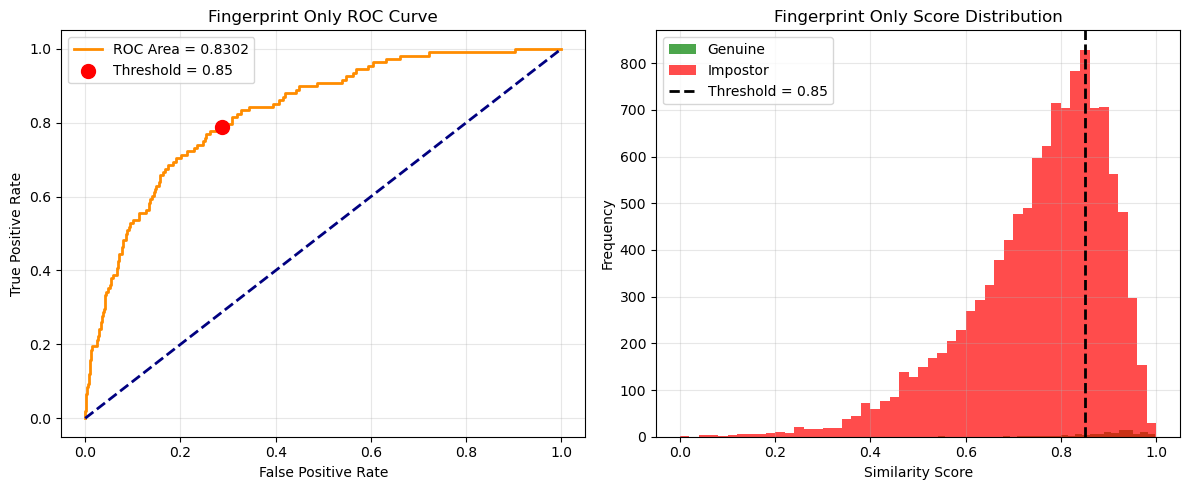


🔍 CASE 2: IRIS ONLY

📊 IRIS ONLY
  ROC-AUC Score:           0.9999
  Equal Error Rate (EER):  0.14%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     108/108 (100.00%)
  Impostor Accept (FP):    66/11556 (0.5711%)
  Accuracy:                99.4342%


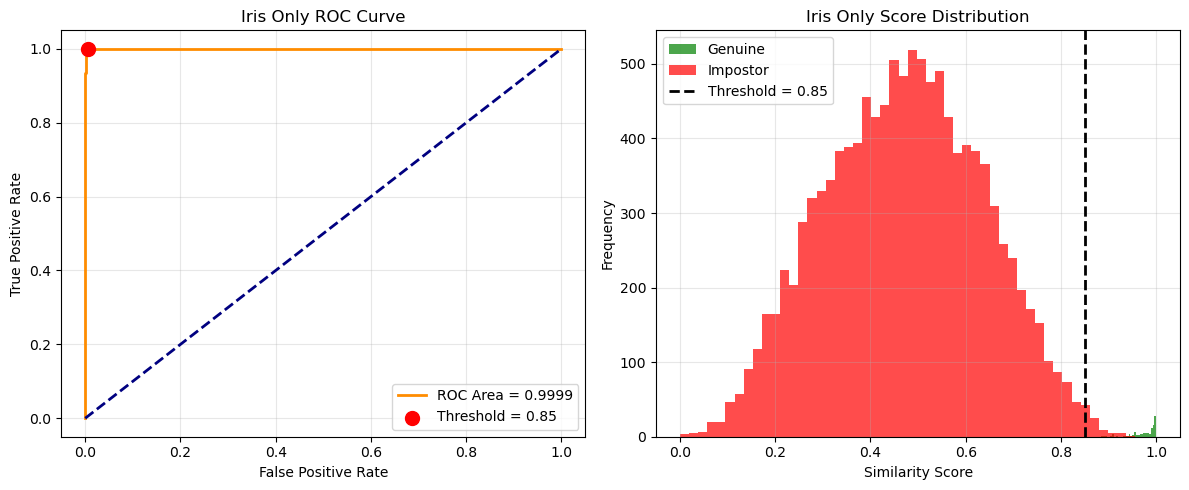


🔍 CASE 3: FUSED

📊 FUSED
  ROC-AUC Score:           0.9999
  Equal Error Rate (EER):  0.24%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     108/108 (100.00%)
  Impostor Accept (FP):    50/11556 (0.4327%)
  Accuracy:                99.5713%


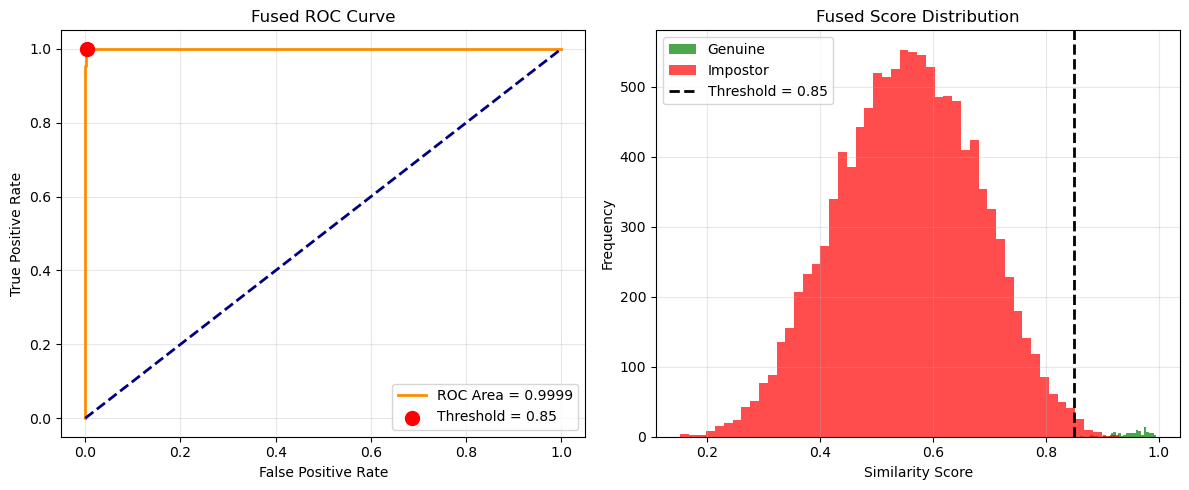


SUMMARY AT THRESHOLD = 0.85
Modality             Accuracy     FAR          ROC-AUC   
-------------------------------------------------------
Fingerprint           71.30%     28.7729%    0.8087
Iris                  99.43%     0.5711%    0.9999
Fused                 99.57%     0.4327%    1.0000


In [9]:
import matplotlib.pyplot as plt

def evaluate_at_threshold(genuine, impostor, threshold):
    gen_scores = np.array(genuine)
    imp_scores = np.array(impostor)
    
    genuine_accept = np.sum(gen_scores >= threshold)
    genuine_reject = len(gen_scores) - genuine_accept
    impostor_accept = np.sum(imp_scores >= threshold)
    impostor_reject = len(imp_scores) - impostor_accept
    
    TPR = genuine_accept / len(gen_scores) if len(gen_scores) > 0 else 0
    FPR = impostor_accept / len(imp_scores) if len(imp_scores) > 0 else 0
    FNR = genuine_reject / len(gen_scores) if len(gen_scores) > 0 else 0
    Accuracy = (genuine_accept + impostor_reject) / (len(gen_scores) + len(imp_scores))
    
    return {'TPR': TPR, 'FPR': FPR, 'FNR': FNR, 'Accuracy': Accuracy,
            'Genuine_Accept': genuine_accept, 'Impostor_Accept': impostor_accept}

def evaluate_and_plot(genuine, impostor, modality_name, fixed_threshold=0.85):
    gen_scores = np.array(genuine)
    imp_scores = np.array(impostor)
    
    labels = np.concatenate([np.ones(len(gen_scores)), np.zeros(len(imp_scores))])
    scores = np.concatenate([gen_scores, imp_scores])
    
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[eer_idx]
    
    result = evaluate_at_threshold(gen_scores, imp_scores, fixed_threshold)
    
    print(f"\n{'='*60}")
    print(f"📊 {modality_name.upper()}")
    print(f"{'='*60}")
    print(f"  ROC-AUC Score:           {roc_auc:.4f}")
    print(f"  Equal Error Rate (EER):  {eer * 100:.2f}%")
    print(f"\n--- At Fixed Threshold = {fixed_threshold:.2f} ---")
    print(f"  Genuine Accept (TP):     {result['Genuine_Accept']}/{len(gen_scores)} ({result['TPR']*100:.2f}%)")
    print(f"  Impostor Accept (FP):    {result['Impostor_Accept']}/{len(imp_scores)} ({result['FPR']*100:.4f}%)")
    print(f"  Accuracy:                {result['Accuracy']*100:.4f}%")
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Area = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'navy', lw=2, linestyle='--')
    plt.scatter(result['FPR'], result['TPR'], color='red', s=100, label=f'Threshold = {fixed_threshold}', zorder=5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{modality_name} ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(gen_scores, bins=30, alpha=0.7, color='green', label='Genuine')
    plt.hist(imp_scores, bins=50, alpha=0.7, color='red', label='Impostor')
    plt.axvline(x=fixed_threshold, color='black', linestyle='--', lw=2, label=f'Threshold = {fixed_threshold}')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title(f'{modality_name} Score Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return result

# Run evaluation
FIXED_THRESHOLD = 0.85

print("=" * 70)
print(f"FINAL EVALUATION WITH FIXED THRESHOLD = {FIXED_THRESHOLD}")
print("=" * 70)

print("\n🔍 CASE 1: FINGERPRINT ONLY")
result_fp = evaluate_and_plot(genuine_scores_fp, impostor_scores_fp, "Fingerprint Only", FIXED_THRESHOLD)

print("\n🔍 CASE 2: IRIS ONLY")
result_ir = evaluate_and_plot(genuine_scores_ir, impostor_scores_ir, "Iris Only", FIXED_THRESHOLD)

print("\n🔍 CASE 3: FUSED")
result_fused = evaluate_and_plot(genuine_scores_fused, impostor_scores_fused, "Fused", FIXED_THRESHOLD)

# Summary
print("\n" + "=" * 70)
print(f"SUMMARY AT THRESHOLD = {FIXED_THRESHOLD}")
print("=" * 70)
print(f"{'Modality':<20} {'Accuracy':<12} {'FAR':<12} {'ROC-AUC':<10}")
print("-" * 55)
print(f"{'Fingerprint':<20} {result_fp['Accuracy']*100:>6.2f}%     {result_fp['FPR']*100:>6.4f}%    {0.8087:.4f}")
print(f"{'Iris':<20} {result_ir['Accuracy']*100:>6.2f}%     {result_ir['FPR']*100:>6.4f}%    {0.9999:.4f}")
print(f"{'Fused':<20} {result_fused['Accuracy']*100:>6.2f}%     {result_fused['FPR']*100:>6.4f}%    {1.0000:.4f}")
print("=" * 70)